In [1]:
from pydantic import BaseModel, Field

# Pydantic을 사용한 State 정의
class AgentState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 작업")
    task_details: str = Field(default="", description="작업 상세 정보")
    response: str = Field(default="", description="응답 결과")

In [2]:
# 노드 함수 정의
def get_llm_response_node(state: AgentState, llm):
    """LLM과 상호작용하여 응답을 생성하거나, 추가 정보를 요청하는 노드"""
    details = state.task_details

    if details:
        print(f"\n상세 정보를 바탕으로 작업 실행: '{details}'")
        prompt = f"다음 요청에 따라 보고서를 작성해주세요: {details}"
    else:
        task = state.user_message
        print(f"\n작업 실행: '{task}' 작업을 수행합니다...")
        # LLM에게 상세 정보를 묻는 질문을 하도록 유도하고, 반드시 '?'로 끝내도록 지시
        prompt = f"'{task}' 작업을 수행하려고 합니다. 어떤 종류의 보고서가 필요한지, 구체적인 주제는 무엇인지 질문해주세요. 추가 정보가 필요하면, 반드시 응답의 마지막을 물음표('?')로 끝내주세요."

    response = llm.invoke(prompt).content

    print("--- LLM 응답 ---")
    print(response)
    print("--------------------")

    return {"response": response, "task_details": ""}

In [3]:
# 사람의 입력을 받는 노드
def get_task_details_node(state: AgentState) -> AgentState:
    """LLM의 질문에 대한 사용자 답변을 입력받는 노드"""
    print("\nLLM의 질문에 답변해주세요.")
    user_input = input("답변: ")
    return {"task_details": user_input}

In [ ]:
from typing import Literal

# 조건부 분기 노드
def check_llm_response(state: AgentState) -> Literal["get_details", "end"]:
    """LLM의 응답이 질문인지 확인하여 다음 단계를 결정합니다."""
    print("LLM 응답 분석 중...")
    if state.response.strip().endswith("?"): # 문자열의 끝이 "?"이면 true
        print("LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.")
        return "get_details"
    print("최종 보고서가 생성되었습니다. 워크플로우를 종료합니다.")
    return "end"

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [6]:
def get_llm_response_with_llm(state):
        return get_llm_response_node(state, model)

In [8]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)
graph_builder.add_node("get_llm_response", get_llm_response_with_llm)
graph_builder.add_node("get_details", get_task_details_node)

graph_builder.add_edge(START, "get_llm_response")
graph_builder.add_conditional_edges(
    "get_llm_response",
    check_llm_response,
    {
        "get_details": "get_details",
        "end": END,
    },
)
graph_builder.add_edge("get_details", "get_llm_response")

In [9]:
graph = graph_builder.compile()

In [ ]:
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

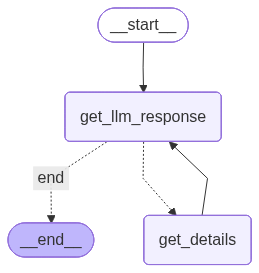

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
final_state = graph.invoke(AgentState(user_message="블로그 글 작성"))


작업 실행: '블로그 글 작성' 작업을 수행합니다...
--- LLM 응답 ---
블로그 글 작성 작업을 위해 어떤 종류의 보고서를 작성해야 하나요? 예를 들어, 데이터 분석 보고서, 시장 조사 보고서, 기술 보고서 등 구체적인 보고서 종류를 알려주세요.

그리고 블로그 글의 구체적인 주제는 무엇인가요? 예를 들어, "최신 AI 기술 동향", "건강한 식습관", "여행지 추천" 등 명확한 주제를 알려주세요.

어떤 독자를 대상으로 하는 블로그인가요? 독자의 연령, 관심사, 지식 수준 등을 알려주시면 글의 내용과 어조를 결정하는 데 도움이 됩니다.

마지막으로, 블로그 글의 목표는 무엇인가요? 예를 들어, 정보 제공, 제품 홍보, 의견 공유 등 목표를 알려주세요.

이 외에 제가 블로그 글을 작성하는 데 필요한 추가 정보가 있나요?
?
--------------------
LLM 응답 분석 중...
LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.

LLM의 질문에 답변해주세요.

상세 정보를 바탕으로 작업 실행: '2025년 KT 소액결제 해킹사건 '
--- LLM 응답 ---
## 2025년 KT 소액결제 해킹 사건 보고서

**1. 사건 개요**

2025년 [월] [일], KT 소액결제 시스템에 대한 대규모 해킹 공격이 발생하여 수백만 건의 사용자 정보 유출 및 금전적 피해가 발생했습니다. 이번 해킹은 KT 소액결제 시스템의 취약점을 악용한 APT (Advanced Persistent Threat) 공격으로 추정되며, 공격자는 장기간에 걸쳐 시스템에 침투하여 사용자 정보를 탈취하고 결제 시스템을 조작한 것으로 밝혀졌습니다.

**2. 사건 발생 경위**

*   **[월] [일]:** KT 소액결제 시스템의 비정상적인 트래픽 증가 및 결제 오류 발생 신고 접수.
*   **[월] [일]:** KT 보안팀은 시스템 분석 결과, 외부로부터의 비정상적인 접근 시도 및 데이터 유출 흔적을 발견하고 해킹 공격 가능성을 인지.
*   **[월] [일]: